 # Tariffs Impact Report Generator



 ## Automated Analysis of Trade Tariff Risks and Corporate Mitigation Strategies

 ## Why It Matters



 In an era of increasing trade tensions and evolving geopolitical landscapes, companies face unprecedented uncertainty around import tariffs and trade barriers. Understanding corporate exposure to tariff risks across global supply chains is critical for investment decisions, risk management, and strategic planning. Manual tracking of tariff impacts across multiple companies and markets is time-intensive and often incomplete.

 ## What It Does



 This workflow combines the `RiskAnalyzer` class from the `bigdata-research-tools` and `GenerateReport` class to systematically analyze corporate exposure to US import tariff risks. Designed for portfolio managers, risk analysts, and trade compliance professionals, it transforms scattered information from news, filings, and earnings calls into structured risk intelligence and actionable mitigation strategies.

 ## How It Works



 The workflow integrates **hybrid semantic search**, **AI-powered risk taxonomies**, and **multi-source content analysis** to deliver:



 - **Automated Risk Taxonomy Creation**: Uses RiskAnalyzer to generate hierarchical risk categories specific to tariff impacts

 - **Cross-Source Intelligence Gathering**: Searches news articles, SEC filings, and earnings transcripts for relevant discussions

 - **AI-Powered Risk Classification**: Categorizes content into specific risk scenarios

 
 - **Corporate Response Extraction**: Identifies and summarizes company mitigation plans from official communications

 - **Customizable Report Generation**: Produces professional HTML reports ranked by Media Attention, Financial Impact, and Uncertainty

 ## A Real-World Use Case



This cookbook demonstrates the complete end-to-end workflow through analyzing how US import tariffs impact major American companies. You'll see how the system transforms scattered tariff discussions across news, SEC filings, and earnings transcripts into structured risk assessments, complete with corporate response strategies and quantified exposure metrics for investment and risk management decisions.

 ## Setup and Imports

 ## Async Compatibility Setup



 **Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:



 ### Why is this needed?



 Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:



 ```

 RuntimeError: asyncio.run() cannot be called from a running event loop

 ```



 The `nest_asyncio.apply()` command patches this to allow nested event loops.



 💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")


✅ nest_asyncio applied


 ## Environment Setup



 The following cell configures the necessary path for the analysis

In [2]:
import os
import sys


current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")


✅ Local environment setup complete


 ## Import Required Libraries



 Import the core libraries needed for tariff risk analysis

In [3]:
from IPython.display import display, HTML
import pandas as pd
import numpy as np
from datetime import datetime

from src.report_generator import GenerateReport, theme_tree_to_dict
from bigdata_client import Bigdata
from bigdata_research_tools.workflows.risk_analyzer import RiskAnalyzer
from bigdata_client.models.search import DocumentType


 ## Optional: Plotly Display Configuration



 For better visualization rendering, you can also set the Plotly renderer:

In [4]:
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")


✅ Plotly configured for Jupyter/VS Code


/opt/anaconda/envs/pricing_power/lib/python3.11/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




 ## Configure Output Directories



 Set up the directory structure where analysis results and reports will be saved.

In [5]:
# Define output file paths for our report
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)


 ## Load Credentials

In [6]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv(script_dir / '.env')

BIGDATA_USERNAME = os.getenv('BIGDATA_USERNAME')
BIGDATA_PASSWORD = os.getenv('BIGDATA_PASSWORD')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_USERNAME, BIGDATA_PASSWORD, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")


✅ Credentials loaded from .env file


 ## Connecting to Bigdata



 Create a Bigdata object with your credentials.

In [ ]:
bigdata = Bigdata(BIGDATA_USERNAME, BIGDATA_PASSWORD)

 ## Defining the Analysis Parameters



 - **Main Theme** (`main_theme`): The central tariff risk scenario to analyze across companies

 - **Focus** (`focus`): Expert perspective for generating targeted risk taxonomies

 - **Company Universe** (`my_watchlist_id`): The set of companies to analyze 

 - **Model Selection** (`llm_model`): The AI model used for risk classification and summarization

 - **Time Period** (`start_date` and `end_date`): The date range for the analysis

- **Frequency** (`freq`): The frequency of the date ranges to search over. Supported values:
    - `Y`: Yearly intervals.
    - `M`: Monthly intervals.
    - `W`: Weekly intervals.
    - `D`: Daily intervals. Defaults to `3M`.

- **Document Limit** (`document_limit`): The maximum number of documents to return per query to Bigdata API.

- **Batch Size** (`batch_size`): The number of entities to include in a single batched query.

 - **Rerank Threshold** (`rerank_threshold`): By setting this value, you’re enabling the cross-encoder which reranks the results and selects those whose relevance is above the percentile you specify (0.7 being the 70th percentile). More information on the re-ranker can be found [here](https://docs.bigdata.com/how-to-guides/rerank_search).


In [ ]:
# ===== Customizable Parameters =====

# Company Universe (from Watchlist)
my_watchlist_id = 'fa589e57-c9e0-444d-801d-18c92d65389f' # Magnificent 7
watchlist = bigdata.watchlists.get(my_watchlist_id)
companies = bigdata.knowledge_graph.get_entities(watchlist.items)

# Main Analysis Theme
main_theme = 'US Import Tariffs Corporate Risk Impact Analysis'
focus = "Provide a detailed taxonomy of risks describing how new American import tariffs will impact worldwide companies, their operations and strategy."

# LLM Model Configuration
llm_model = "openai::gpt-4o-mini"

# Time Range Configuration
start_date = "2025-02-01"
end_date = "2025-06-13"
freq = 'M'  # Monthly search frequency

#  Enable/Disable Reranker 
rerank_threshold = None

# Document Retrieval Limits
document_limit_news = 10
document_limit_filings = 5
batch_size = 1



 ## Risk Analysis



 The first phase uses the `RiskAnalyzer` class to establish the foundation for our tariff impact analysis. This phase includes three critical steps that prepare the data for the report generation phase.

 ### Initialize RiskAnalyzer



 The `RiskAnalyzer` handles the initial risk discovery and taxonomy creation:

 - **Automated Taxonomy Generation**: Creates a hierarchical structure of tariff-related risks

 - **Semantic Content Retrieval**: Searches news articles using AI-powered semantic matching

 - **Intelligent Content Labeling**: Categorizes found content into specific risk scenarios




In [9]:
# Initialize RiskAnalyzer with tariff-specific parameters
analyzer = RiskAnalyzer(
    llm_model=llm_model,
    main_theme=main_theme,
    companies=companies,
    start_date=start_date,
    end_date=end_date,
    document_type=DocumentType.NEWS,
    sources=None,
    rerank_threshold=None,
    focus=focus,
)


 ### Generate Risk Taxonomy



 Create a comprehensive taxonomy that breaks down tariff risks into specific, analyzable categories such as supply chain disruption, pricing impacts, and market access challenges.

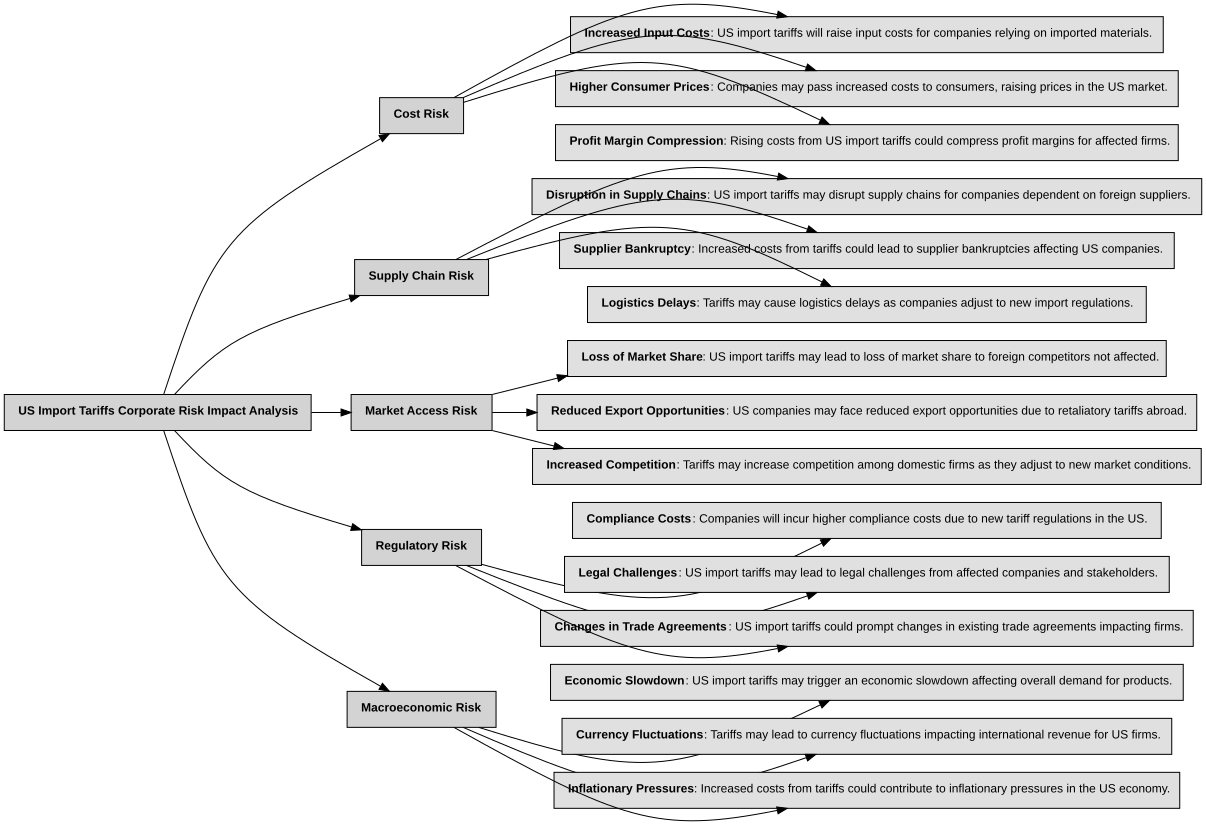

In [10]:
# Generate the comprehensive risk taxonomy
risk_tree, risk_summaries, terminal_labels = analyzer.create_taxonomy()
themes_tree_dict = {risk_tree.label: theme_tree_to_dict(risk_tree)}

# Visualize the taxonomy structure
risk_tree.visualize()


 The taxonomy tree shows how tariff risks branch into specific sub-scenarios. Each terminal node represents a distinct risk category that will be used to classify and analyze news content.

 ### Retrieve Relevant Content



 Search news articles using the generated taxonomy to find discussions about tariff impacts across our company universe.

In [11]:
# Search for tariff-related content in news articles
df_sentences_semantic = analyzer.retrieve_results(
    sentences=risk_summaries,
    freq=freq,
    document_limit=document_limit_news,
    batch_size=batch_size
)


[AbsoluteDateRange('2025-02-01T00:00:00', '2025-02-28T23:59:59'), AbsoluteDateRange('2025-03-01T00:00:00', '2025-03-31T23:59:59'), AbsoluteDateRange('2025-04-01T00:00:00', '2025-04-30T23:59:59'), AbsoluteDateRange('2025-05-01T00:00:00', '2025-05-31T23:59:59'), AbsoluteDateRange('2025-06-01T00:00:00', '2025-06-13T23:59:59')]


Processing news results...: 100%|██████████| 5250/5250 [00:00<00:00, 12864.75it/s]


 ### Labeling
 
 Use AI to analyze each news excerpt and categorize it into the appropriate risk scenarios. This creates structured data from unstructured news content.

In [12]:
# Classify news content into risk categories
df_labeled, _ = analyzer.label_search_results(
    df_sentences=df_sentences_semantic,
    terminal_labels=terminal_labels,
    risk_tree=risk_tree,
    additional_prompt_fields=['entity_sector','entity_industry', 'headline']
)


Querying OpenAI...:   0%|          | 0/3046 [00:00<?, ?it/s]

Querying OpenAI...: 100%|██████████| 3046/3046 [02:44<00:00, 18.57it/s]


 ## Report Generation

 The second phase uses `GenerateReport` and transforms the classified risk data into comprehensive reports with corporate mitigation strategies.

 ### Initialize GenerateReport



 The `GenerateReport` class will:

 - Create sector-wide risk summaries

 - Generate company-specific risk scores and summaries

 - Extract mitigation plans from SEC filings and earnings transcripts

 - Produce professional HTML reports with customizable ranking criteria

In [13]:
# Initialize the report generator with our analysis parameters
report_generator = GenerateReport(
        watchlist_id=my_watchlist_id,
        main_theme=main_theme,
        focus=focus,
        llm_model='gpt-4o-mini',
        api_key=OPENAI_API_KEY,
        start_date=start_date,
        end_date=end_date,
        search_frequency=freq,
        document_limit_news=document_limit_news,
        document_limit_filings=document_limit_filings,
        bigdata=bigdata,
        batch_size=batch_size,
        themes_tree_dict=themes_tree_dict
)


 ### Generate Comprehensive Report



 Execute the complete report generation workflow including:

 1. **Sector-Level Summarization**: Create thematic summaries across risk categories

 2. **Company-Level Analysis**: Generate risk scores for Media Attention, Financial Impact, and Uncertainty

 3. **Mitigation Strategy Extraction**: Search filings and transcripts for corporate response plans

 4. **Data Integration**: Combine all sources into structured report datasets

In [14]:
# Generate the complete risk report
report = report_generator.generate_report(
    df_labeled=df_labeled,
    import_from_path=None,
    export_to_path=output_dir,
)

test
entity id='228D42' name='Microsoft Corp.' volume=None description='Microsoft Corp., is an American multinational software corporation headquartered in Redmond, Washington that develops, manufactures, licenses, and supports a wide range of products and services related to computing. The company was incorporated on June 25, 1981.' entity_type='COMP' company_type='Public' country='United States' sector='Technology' industry_group='Software' industry='Software' ticker='MSFT' webpage='http://www.microsoft.com' isin_values=['AU0000004574', 'CA59516M1041', 'TH0150121109', 'US5949181045'] cusip_values=['594918104', '59516M104', 'P0R682363', 'Q3R79Y132', 'Y49876181'] sedol_values=['2588173', '2668398', '5925205', '6257866', 'BGHHBL3', 'BPGZV88', 'BPLLQL9'] listing_values=['NEOE:MSFT', 'XHKG:04338', 'XHKG:4338', 'XMEX:MSFT', 'XNAS:MSFT', 'XNMS:MSFT']
len(list_sentences) 15
list_sentences ['US import tariffs will raise input costs for companies relying on imported materials.', 'Companies may

Querying Bigdata...: 100%|██████████| 75/75 [00:14<00:00,  5.14it/s]


entity id='4A6F00' name='Alphabet Inc.' volume=None description='Alphabet Inc. (formerly Google Inc.) operates as a technology conglomerate, providing various services for people and businesses. It was founded on September 4, 1998. After a reorganization of Google on October 2, 2015, Alphabet Inc. became the parent company of Google and several former Google subsidiaries.' entity_type='COMP' company_type='Public' country='United States' sector='Technology' industry_group='Internet Services' industry='Internet Services' ticker='GOOGL' webpage='http://www.abc.xyz' isin_values=['ARDEUT116159', 'BRGOGLBDR001', 'BRGOGLBDR019', 'CA02080K1049', 'TH0150120903', 'TH0809121302', 'US02079K1079', 'US02079K2069', 'US02079K3059', 'US38259P2011', 'US38259P3001', 'US38259P4090'] cusip_values=['02079K107', '02079K206', '02079K305', '02080K104', '38259P201', '38259P300', '38259P409', 'P0R684351', 'Y100G4337', 'Y49876173'] sedol_values=['B043K04', 'BL25KS7', 'BNC31T3', 'BPLLP90', 'BVBCP40', 'BYV1PK4', 'B

Querying Bigdata...: 100%|██████████| 75/75 [00:14<00:00,  5.29it/s]


entity id='0157B1' name='Amazon.com Inc.' volume=None description='Amazon.com Inc. is a multinational technology company focusing in e-commerce, cloud computing, and artificial intelligence. The company was incorporated on July 5, 1994.' entity_type='COMP' company_type='Public' country='United States' sector='Consumer Services' industry_group='General Retailers' industry='Internet & Direct Marketing Retail' ticker='AMZN' webpage='http://www.amazon.com' isin_values=['AU0000048530', 'CA02315E1051', 'TH0150121307', 'TH0809121401', 'TH0842120105', 'US0231351067'] cusip_values=['023135106', '02315E105', 'P0R686174', 'Q3R79Y207', 'Y100G4345', 'Y476JC223', 'Y49876231'] sedol_values=['2000019', '2436368', 'B01YWR1', 'B58WM62', 'BJ9K865', 'BNC31M6', 'BR1WCN0', 'BS7ZCZ2', 'BVBDDH2'] listing_values=['XBKK:AMZN01', 'XBKK:AMZN06', 'XBKK:AMZN80', 'XBOG:AMZN', 'XLIM:AMZN', 'XMEX:AMZN', 'XNAS:AMZN', 'XNMS:AMZN']
len(list_sentences) 15
list_sentences ['US import tariffs will raise input costs for compa

...

entity id='D8442A' name='Apple Inc.' volume=None description='Apple Inc. (formerly Apple Computer Inc.), incorporated on January 03, 1977, designs, manufactures, and markets mobile communication and media devices, personal computing products, and portable digital music players worldwide.' entity_type='COMP' company_type='Public' country='United States' sector='Technology' industry_group='Computer Hardware' industry='Computer Hardware' ticker='AAPL' webpage='http://www.apple.com' isin_values=['CA03785Y1007', 'TH0150120408', 'TH0809121500', 'US0378331005'] cusip_values=['037833100', '03785Y100', 'P0R684385', 'Y100G4352', 'Y49876132'] sedol_values=['2046251', 'BNC31R1', 'BPXWT99', 'BVBDDG1'] listing_values=['XBKK:AAPL80', 'XNAS:AAPL']
len(list_sentences) 15
list_sentences ['US import tariffs will raise input costs for companies relying on imported materials.', 'Companies may pass increased costs to consumers, raising prices in the US market.', 'Rising costs from US import tariffs could co

Querying Bigdata...: 100%|██████████| 75/75 [00:14<00:00,  5.25it/s]


entity id='12E454' name='Meta Platforms Inc.' volume=None description='Meta Platforms Inc. (formerly Facebook Inc.) is an American multinational technology company. The company engages in the development of social media applications for people to connect through mobile devices, personal computers, and other surfaces. The company was incorporated on July 29, 2004 as TheFacebook Inc.' entity_type='COMP' company_type='Public' country='United States' sector='Technology' industry_group='Internet Services' industry='Internet Services' ticker='META' webpage='http://www.meta.com' isin_values=['BRM1TABDR009', 'CA59101A1012', 'TH0150121505', 'TH0809121609', 'TH0842120303', 'US30303M1027'] cusip_values=['30303M102', '59101A101', 'P0R67N699', 'Y100G4360', 'Y476JC249', 'Y49876215'] sedol_values=['B7TL820', 'BMCJRW9', 'BMGDF78', 'BNZJ4X3', 'BR1WCC9', 'BSJC7H8', 'BVF8ZC2'] listing_values=['NEOE:MVRS', 'XBKK:META06', 'XBKK:META80', 'XETR:FB2A', 'XFRA:FB2A', 'XLON:0QZI', 'XNAS:META', 'XWBO:META']
len(l

Querying Bigdata...: 100%|██████████| 75/75 [00:14<00:00,  5.17it/s]


Completed 62 requests in 4.65 seconds.
Completed 178 requests in 6.29 seconds.
Completed 123 requests in 13.75 seconds.
Completed 182 requests in 5.04 seconds.
Completed 65 requests in 6.36 seconds.
Completed 53 requests in 3.99 seconds.
Completed 121 requests in 4.42 seconds.
Completed 87 requests in 9.83 seconds.
Completed 234 requests in 5.23 seconds.
Completed 116 requests in 8.18 seconds.
Completed 200 requests in 6.63 seconds.
Completed 62 requests in 7.16 seconds.
Completed 63 requests in 4.06 seconds.
Completed 80 requests in 5.12 seconds.


 ## Final Output

 Transform the analysis results into professional, customizable reports. The system provides two distinct presentation styles, each optimized for different use cases and audiences.

 ### Report Customization Options



 Both report formats allow customization through multiple ranking criteria:



 **Sector-Wide Analysis**:

 - Identifies the most significant tariff risks across all companies

 - Ranks themes by media attention and document frequency

 - Provides executive summaries for each risk category



 **Company-Specific Analysis**:

 - **Most Reported Issue**: Highest media coverage and attention

 - **Biggest Risk**: Greatest potential financial impact

 - **Most Uncertain Issue**: Highest uncertainty scores and ambiguity



 Each company analysis includes extracted mitigation plans from official corporate communications, providing actionable intelligence for investment and risk management decisions.

 ### Report Format 1: Executive Summary Style



 This format prioritizes clarity and executive readability, focusing on the top risks per company across three key dimensions. Ideal for senior management briefings and board presentations.

In [15]:
from src.html_report import generate_html_report, prepare_data_report_0

# Extract report data for processing
df_by_theme = report.report_by_theme
df_by_company_with_responses = report.report_by_company

# Prepare data with executive summary formatting
top_by_theme, top_by_company = prepare_data_report_0(df_by_theme, df_by_company_with_responses)

# Generate executive-style HTML report
html_content = generate_html_report(top_by_theme, top_by_company, 'US Import Tariffs: Corporate Risk Impact Analysis')

# Save the executive report
report_filename = f'{output_dir}/tariffs_executive_report.html'
with open(report_filename, 'w') as file:
     file.write(html_content)

print(f"✅ Executive Report saved: {report_filename}")


✅ Executive Report saved: output/tariffs_executive_report.html


 #### Display Executive Report

In [16]:
display(HTML(html_content))


 ### Report Format 2: Detailed Analysis Version



 This format provides comprehensive risk analysis with extended company coverage and detailed risk breakdowns. Designed for analysts, portfolio managers, and risk management teams requiring in-depth insights.

In [17]:
from src.html_report import generate_html_report_v1, prepare_data_report_1

# Prepare data with detailed analysis formatting
top_by_theme, top_by_company = prepare_data_report_1(df_by_theme, df_by_company_with_responses)

# Generate detailed analysis HTML report
html_content_detailed = generate_html_report_v1(top_by_theme, top_by_company, 'US Import Tariffs: Comprehensive Risk Analysis')

# Save the detailed report
detailed_filename = f'{output_dir}/tariffs_detailed_analysis.html'
with open(detailed_filename, 'w') as file:
     file.write(html_content_detailed)

print(f"✅ Detailed Analysis Report saved: {detailed_filename}")


✅ Detailed Analysis Report saved: output/tariffs_detailed_analysis.html


 #### Display Detailed Analysis Report

In [18]:
display(HTML(html_content_detailed))



 ## Conclusion



 This workflow demonstrates a comprehensive approach to tariff risk analysis that combines the analytical power of **RiskAnalyzer** with the report generation capabilities of **GenerateReport**.



 ### Key Outcomes:



 1. **Structured Risk Intelligence**: Automated conversion of unstructured news and corporate communications into quantified risk metrics

 2. **Actionable Mitigation Strategies**: Extraction of specific corporate response plans from SEC filings and earnings transcripts

 3. **Investment-Ready Reports**: Professional HTML outputs suitable for portfolio decisions and risk management

 4. **Scalable Analysis**: Framework applicable to any trade policy scenario or company watchlist



 ### Business Applications:



 - **Portfolio Risk Management**: Identify and hedge against tariff-exposed holdings

 - **Investment Strategy**: Target opportunities in companies with strong mitigation plans

 - **Policy Impact Assessment**: Quantify potential effects of trade policy changes

 - **Competitive Intelligence**: Track how industry peers respond to trade challenges



 This integrated approach provides the depth of academic research with the speed and scale needed for modern financial decision-making.

 ### Export Results for Further Analysis



 The generated data can be exported for integration with existing risk management systems, portfolio optimization tools, or compliance reporting workflows.

In [19]:
# Optional: Export structured data for external analysis
try:
    # Export the core datasets
    df_by_theme.to_csv(f'{output_dir}/tariffs_risks_by_theme.csv', index=False)
    df_by_company_with_responses.to_csv(f'{output_dir}/tariffs_risks_by_company.csv', index=False)
    
    print("✅ Data exported successfully:")
    print(f"   - Thematic analysis: {output_dir}/tariffs_risks_by_theme.csv")
    print(f"   - Company analysis: {output_dir}/tariffs_risks_by_company.csv")
    print(f"   - Executive report: {output_dir}/tariffs_executive_report.html")
    print(f"   - Detailed analysis: {output_dir}/tariffs_detailed_analysis.html")
    
except Exception as e:
    print(f"Warning: Export failed - {e}")


✅ Data exported successfully:
   - Thematic analysis: output/tariffs_risks_by_theme.csv
   - Company analysis: output/tariffs_risks_by_company.csv
   - Executive report: output/tariffs_executive_report.html
   - Detailed analysis: output/tariffs_detailed_analysis.html
